In [1]:
import pandas as pd
from src.data import DATA_DIR_INTERIM

from src.io import load_qrels_from_path, read_metadata
from topic_gen.evaluate import MetaExperiment
from topic_gen.evaluate.io import load_from_irds
from topic_gen.evaluate.measures_agreement import CohenKappa, AreaUnderReceiver, MeanAverageError
from topic_gen.evaluate.measures_agreement_multiple import LabelDistribution
from topic_gen.evaluate.utils import QrelsTransformer

from topic_gen import logger
logger.setLevel("DEBUG")

### Binary Relevance Labels

In [2]:
BASE_DIR = DATA_DIR_INTERIM / "dl19" / "qrels-dl19-topics-generated"
experiments = load_qrels_from_path(
    BASE_DIR, binarize_qrels=2, drop_relevance_values=999)

Error loading experiment from 2025-12-10_06:31:40: [Errno 2] No such file or directory: '/workspaces/conf26-generating-topics/data/interim/dl19/qrels-dl19-topics-generated/2025-12-10_06:31:40/qrels.csv.gz'


In [3]:
baseline = load_from_irds("msmarco-passage/trec-dl-2019/judged", binarize_qrels=2)
baseline.qrels = QrelsTransformer.drop_relevance(
    baseline.qrels, drop_values=999)

In [4]:
meta_exp = MetaExperiment(
    experiments=experiments,
    baseline=baseline,
    measures=[CohenKappa(), AreaUnderReceiver(), MeanAverageError(), LabelDistribution()],
    filter_qrels=True
)

In [5]:
res = meta_exp.evaluate()

/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [6]:
metadata = read_metadata(BASE_DIR)

[topic_gen] [WARNING] (io.py:45) Metadata not found for result 2025-12-10_06:31:40, skipping...


In [7]:
df = pd.DataFrame(res)
# df["score"] = df.apply(format_score, axis=1)
df = df.pivot(index="name", columns="measure", values="value").reset_index()
df = df.merge(metadata, left_on="name", right_on="date", how="left")

In [8]:
df["model"].unique()

array(['qwen3-14B-no-think', 'gpt-oss-20B', 'qwen3-30B-no-think',
       'gpt-oss-120B-ollama', 'deepseek-V3.2', nan], dtype=object)

## **Alignment:** How well align generated qrels based on generated topics with the original qrels?
 
- Judgments based on the original topics are always better but sometimes just a little!
- More context is allmost allways better
- Only not relevant documents works not well but in conjunction with relevant documents it actually does!
- For contrastive prompting, query variants can be substituded with more documents
- Query variants and relevant documents are the most important context information.
- Query variants with positive documents perfomrs the best followed by contrastive with variants 

In [9]:
model = "qwen3-30B-no-think"  # df["model"]
prompt_sorter = [
    "human",
    "topic-query",
    "topic-docs-pos",
    "topic-docs-neg",
    "topic-query-docs-pos",
    "topic-query-docs-neg",
    "topic-contrastive",
    "topic-query-contrastive"
]
tab = df.copy()
tab["topics_prompt"] = pd.Categorical(tab["topics_prompt"], prompt_sorter)

tab[#(tab["prompt"] == "qrel_zeroshot_bing") & \
# (tab["model"] == model) &
   ((tab["model"] == tab["topics_model"]) | (tab["topics_model"] == "human") | (tab["name"] == "msmarco-passage/trec-dl-2019/judged"))] \
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["model", "topics_prompt", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver", "label_dist(0)", "label_dist(1)"]].round(2)

,model,topics_prompt,topics_nqueries,topics_ndocspos,topics_ndocsneg,CohenKappa,MeanAverageError,AreaUnderReceiver,label_dist(0),label_dist(1)
4,deepseek-V3.2,human,NaN,NaN,NaN,0.46,0.24,0.72,0.63,0.37
3,gpt-oss-120B-ollama,human,NaN,NaN,NaN,0.53,0.19,0.76,0.71,0.29
1,gpt-oss-20B,human,NaN,NaN,NaN,0.49,0.21,0.74,0.70,0.30
149,gpt-oss-20B,topic-query,1.0,0.0,0.0,0.51,0.21,0.74,0.67,0.33
150,gpt-oss-20B,topic-docs-pos,0.0,1.0,0.0,0.23,0.29,0.63,0.78,0.22
151,gpt-oss-20B,topic-docs-pos,0.0,2.0,0.0,0.23,0.27,0.64,0.83,0.17
152,gpt-oss-20B,topic-docs-pos,0.0,3.0,0.0,0.20,0.28,0.62,0.81,0.19
153,gpt-oss-20B,topic-docs-pos,0.0,4.0,0.0,0.31,0.26,0.66,0.76,0.24
154,gpt-oss-20B,topic-docs-pos,0.0,5.0,0.0,0.22,0.28,0.62,0.80,0.20
155,gpt-oss-20B,topic-docs-neg,0.0,0.0,1.0,-0.01,0.28,0.49,0.97,0.03


## Plot 

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.DataFrame(res)
df = df.merge(metadata, left_on="name", right_on="date")

In [12]:
df = df[(df["prompt"] == "qrel_zeroshot_bing") & ((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))]

In [13]:
models = df["model"].unique()
colors = sns.color_palette("tab10", len(models))
model_colors = dict(zip(models, colors))

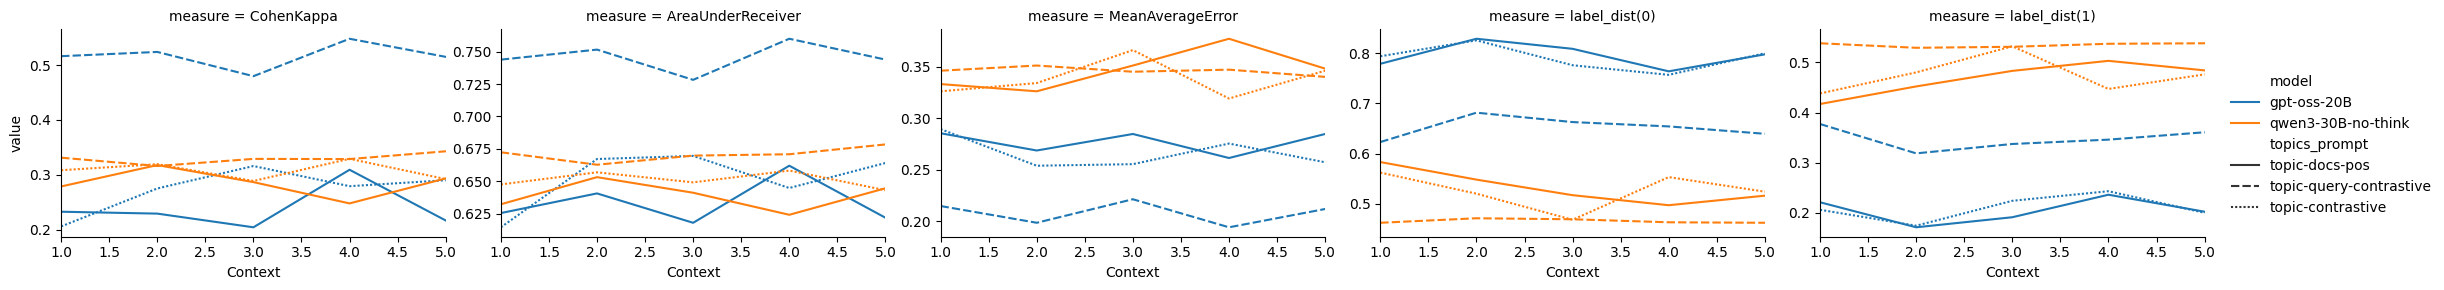

In [14]:
g = sns.relplot(
    data=df[df["topics_prompt"].isin(['topic-query-contrastive','topic-contrastive', "topic-docs-pos"])],
    x="topics_ndocspos",
    y="value",
    hue="model",
    style="topics_prompt",
    col="measure",
    kind="line",
    height=3,
    palette=model_colors,
    aspect=1.5,
    facet_kws={"sharey": False},
)

for ax in g.axes.flatten():
    ax.set_xbound(1,5)
    ax.set_xlabel("Context")
#     title = ax.get_title()
#     measure = title.split(" = ")[1].replace(" | field", "")
#     if measure in y_mins:
#         ax.set_ylim(bottom=y_mins[measure])


plt.show()

In [15]:
def plot(subset_prompt_list, df, x="topics_ndocspos"):
    df = df.copy()
    baseline = df[df["topics_prompt"] == "human"]
    df = df[df["topics_prompt"].isin(subset_prompt_list)]
    unique_prompts = df["topics_prompt"].unique()
    palette = sns.color_palette("tab10", len(unique_prompts))
    color_map = dict(zip(unique_prompts, palette))

    for measure_name, g in df.groupby("measure"):
        fig, ax = plt.subplots(figsize=(6, 4))
        g = g.copy()
        # g['ci_lower'] = g['value'] - g['ci']
        # g['ci_upper'] = g['value'] + g['ci']

        sns.lineplot(
            data=g,
            x=x,
            y="value",
            hue="topics_prompt",
            palette=color_map,
            ax=ax,
            errorbar=None,
            marker='o'
        )
        # for prompt_name, sub_g in g.groupby("topics_prompt"):
        #     sub_g = sub_g.sort_values(x)
        #     color = color_map[prompt_name]

        #     ax.fill_between(
        #         sub_g[x],
        #         sub_g['ci_lower'],
        #         sub_g['ci_upper'],
        #         color=color,
        #         alpha=0.15
        #     )

        ax.axhline(y=float(baseline[baseline["measure"] == measure_name]["value"].iloc[0]), linestyle='--',
                   label=f"Original Topic", color='gray')
        ax.set_title(f"Measure: {measure_name}")
    return baseline

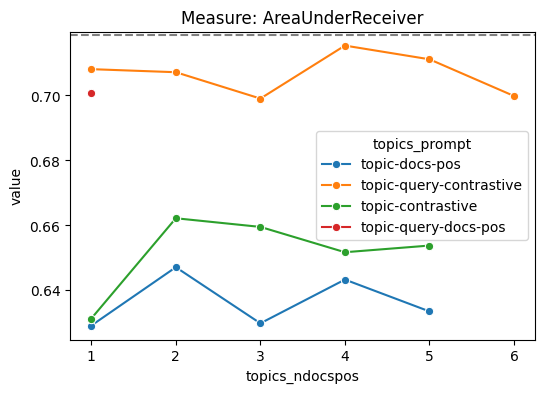

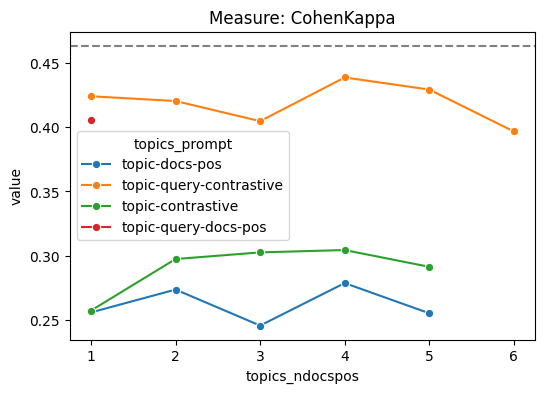

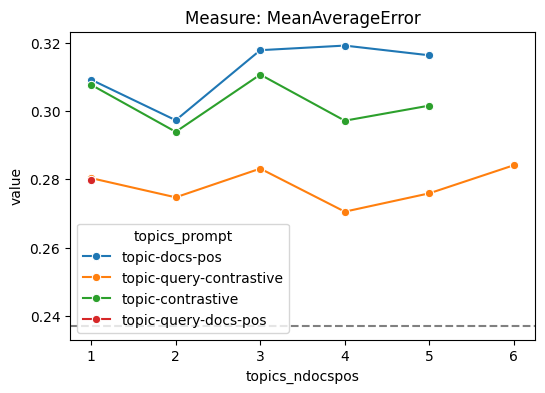

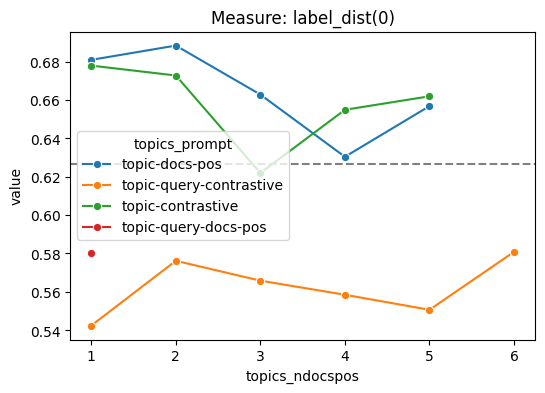

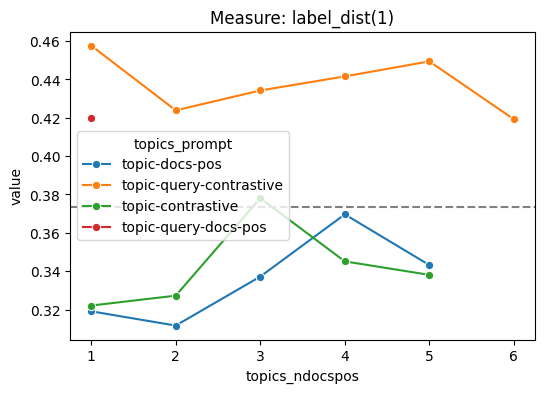

In [16]:
b = plot(['topic-query-docs-pos', 'topic-query-contrastive','topic-contrastive', "topic-docs-pos"], df)

,name,measure,value,missing_topics,missing_qrels,date,model,data,prompt,k,...,topics_date,topics_model,topics_data,topics_prompt,topics_k,topics_nqueries,topics_ndocspos,topics_ndocsneg,topics_output,topics_task
32,2025-12-10_06:31:57,CohenKappa,0.463162,0,0,2025-12-10_06:31:57,deepseek-V3.2,dl19,qrel_zeroshot_bing,None,...,2025-12-10_06:31:57,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
82,2025-12-05_15:15:10,CohenKappa,0.508248,0,18,2025-12-05_15:15:10,qwen3-14B-no-think,dl19,qrel_zeroshot_bing,None,...,2025-12-05_15:15:10,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
96,2025-12-09_07:24:09,CohenKappa,0.533470,0,1,2025-12-09_07:24:09,gpt-oss-120B-ollama,dl19,qrel_zeroshot_bing,None,...,2025-12-09_07:24:09,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
185,2025-12-09_06:32:42,CohenKappa,0.366478,0,0,2025-12-09_06:32:42,qwen3-30B-no-think,dl19,qrel_zeroshot_bing,None,...,2025-12-09_06:32:42,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
239,2025-12-07_16:20:49,CohenKappa,0.489429,0,26,2025-12-07_16:20:49,gpt-oss-20B,dl19,qrel_zeroshot_bing,None,...,2025-12-07_16:20:49,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
277,2025-12-10_06:31:57,AreaUnderReceiver,0.718636,0,0,2025-12-10_06:31:57,deepseek-V3.2,dl19,qrel_zeroshot_bing,None,...,2025-12-10_06:31:57,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
327,2025-12-05_15:15:10,AreaUnderReceiver,0.742786,0,18,2025-12-05_15:15:10,qwen3-14B-no-think,dl19,qrel_zeroshot_bing,None,...,2025-12-05_15:15:10,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
341,2025-12-09_07:24:09,AreaUnderReceiver,0.761177,0,1,2025-12-09_07:24:09,gpt-oss-120B-ollama,dl19,qrel_zeroshot_bing,None,...,2025-12-09_07:24:09,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
430,2025-12-09_06:32:42,AreaUnderReceiver,0.685466,0,0,2025-12-09_06:32:42,qwen3-30B-no-think,dl19,qrel_zeroshot_bing,None,...,2025-12-09_06:32:42,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics
484,2025-12-07_16:20:49,AreaUnderReceiver,0.737593,0,26,2025-12-07_16:20:49,gpt-oss-20B,dl19,qrel_zeroshot_bing,None,...,2025-12-07_16:20:49,human,dl19,human,None,NaN,NaN,NaN,../data/interim/dl19/qrels-dl19-reference,topics


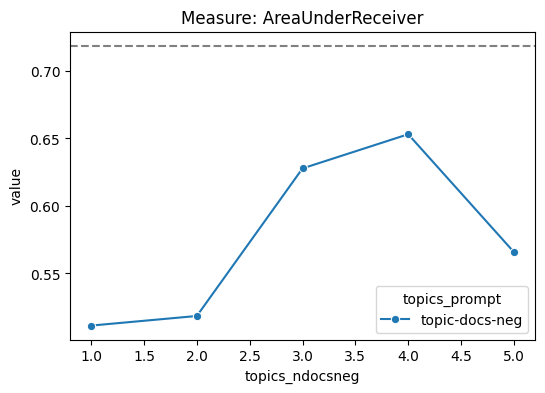

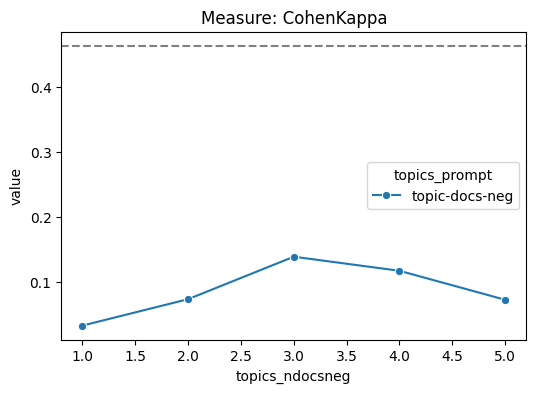

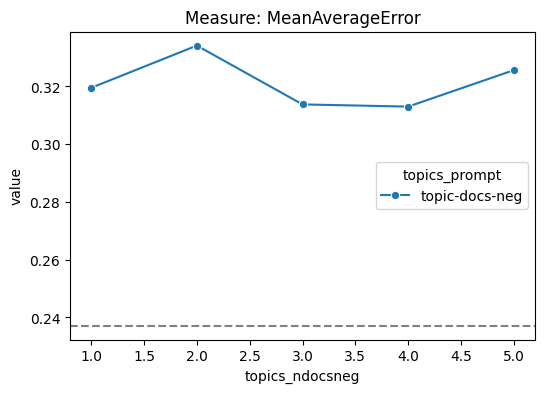

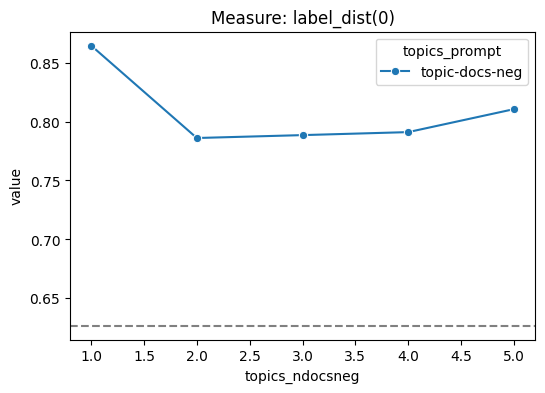

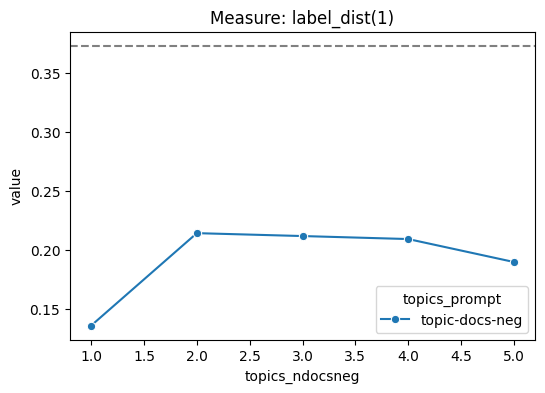

In [17]:
plot(['topic-docs-neg'], df, x="topics_ndocsneg")